### Register and preprocess the final healthy b1000 dataset

In [1]:
import os
import glob

import ants

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import nibabel as nib

import SimpleITK as sitk

from skimage.transform import resize

from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

### Utility functions

In [3]:
def resample_img(itk_image, out_spacing=[1.0, 1.0, 1.0]):
    # Resample images to 2mspecified spacing with SimpleITK

    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
        int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(itk_image.GetDirection())
    resample.SetOutputOrigin(itk_image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(itk_image.GetPixelIDValue())


    resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(itk_image)

In [4]:
def register_nifti_files(fixed_reference, dataset_path, output_path, register_masks=False, dataset_masks_path=None, output_masks_path=None):
    """
    Registers all NIfTI files in the dataset_path folder to the same space using ANTs.

    Parameters:
    - dataset_path: Path to the folder containing NIfTI files.
    - output_path: Path to save the registered NIfTI files.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Get all NIfTI files in the dataset_path
    nifti_files = sorted(glob.glob(os.path.join(dataset_path, "*.nii*")))
    if register_masks:
        nifti_masks_files = sorted(glob.glob(os.path.join(dataset_masks_path, "*.nii*")))
    #print("nifti_files", nifti_files)
    if register_masks: print("nifti_masks_files", nifti_masks_files)
    if not nifti_files:
        print("No NIfTI files found in the dataset path.")
        return

    # Use the first file as the fixed image (reference)
    fixed_image = ants.image_read(fixed_reference)

    for i, moving_file in enumerate(tqdm(nifti_files)):
        
        output_filepath = os.path.join(output_path, os.path.basename(moving_file))

        if register_masks:
            mask_file = nifti_masks_files[i]
            output_mask_filepath = os.path.join(output_masks_path, os.path.basename(mask_file))
        
        
        if not os.path.isfile(output_filepath):
            moving_image = ants.image_read(moving_file)
            
            # Perform registration
            registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

            # for the mask
            if register_masks:
                mask_image = ants.image_read(mask_file)
                transform = registration['fwdtransforms']
                mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
                mask_moved.to_file(output_mask_filepath)

            # Save the registered image
            ants.image_write(registration['warpedmovout'], output_filepath)
    
            #print(f"Registered {moving_file} and saved to {output_filepath}")
        else:
            print("skipped registration already done")


### Template (histogram matching to b1000 from ixi)

(197, 233, 189)


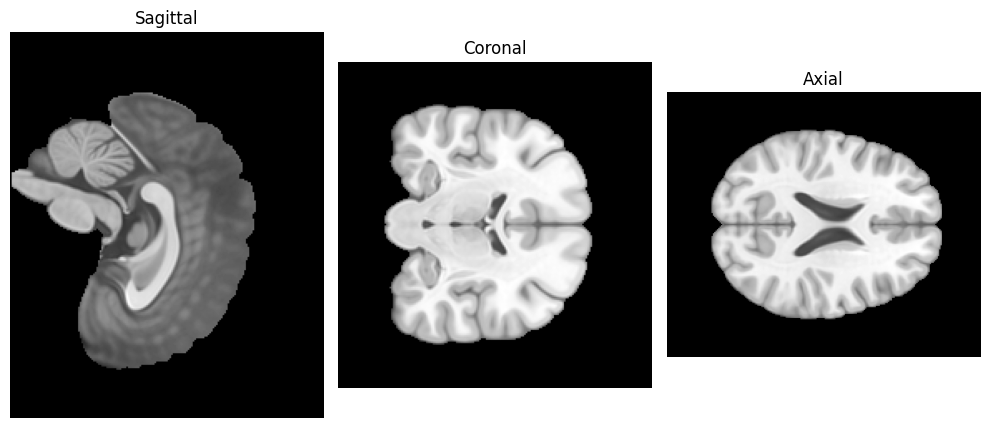

In [45]:
template_path = ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/mni_icbm152_t1_skullstrip.nii.gz"
template_img = nib.load(template_path)
template_data = template_img.get_fdata()
print(template_data.shape)
fig, axes = plt.subplots(1, 3, figsize=(10, 10))

# Axial slice
axes[0].imshow(template_data[template_data.shape[0] // 2, :, :], cmap="gray")
axes[0].set_title("Sagittal")
axes[0].axis("off")

# Sagittal slice
axes[1].imshow(template_data[:, template_data.shape[1] // 2, :], cmap="gray")
axes[1].set_title("Coronal")
axes[1].axis("off")

# Coronal slice
axes[2].imshow(template_data[:, :, template_data.shape[2] // 2], cmap="gray")
axes[2].set_title("Axial")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [57]:
# Load, pad to (233, 233, 233), then resize to (128, 128, 128)
img = nib.load(template_path)
data = img.get_fdata()

def center_pad_to_shape(arr, target_shape, cval=0):
    # Center-crop if larger, then center-pad if smaller
    slices = []
    for c, t in zip(arr.shape, target_shape):
        if c > t:
            start = (c - t) // 2
            slices.append(slice(start, start + t))
        else:
            slices.append(slice(0, c))
    cropped = arr[tuple(slices)]
    pad_width = []
    for c, t in zip(cropped.shape, target_shape):
        pad = max(t - c, 0)
        pad_width.append((pad // 2, pad - pad // 2))
    return np.pad(cropped, pad_width, mode="constant", constant_values=cval)

padded_template = center_pad_to_shape(data, (233, 233, 233), cval=0)
resized_template_128 = resize(
    padded_template,
    (128, 128, 128),
    order=3,
    mode="constant",
    cval=0,
    anti_aliasing=True,
    preserve_range=True,
).astype(data.dtype)

print("Original shape:", data.shape)
print("Padded shape:", padded_template.shape)
print("Resized shape:", resized_template_128.shape)

# Save the resized image
resized_img_128 = nib.Nifti1Image(resized_template_128, img.affine, img.header)
resized_img_128_path = ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_mni_icbm152_t1_skullstrip.nii.gz"
nib.save(resized_img_128, resized_img_128_path)
print(f"Resized image saved to {resized_img_128_path}")

Original shape: (197, 233, 189)
Padded shape: (233, 233, 233)
Resized shape: (128, 128, 128)
Resized image saved to /home/fehrdelt/bettik/datasets/mni_icbm152_nlin_sym_09a/128_mni_icbm152_t1_skullstrip.nii.gz


In [58]:
# resample the template to 1x1x1.5mm3
template_image_path = ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_mni_icbm152_t1_skullstrip.nii.gz"
itk_template_image = sitk.ReadImage(template_image_path)
resampled_template = resample_img(itk_template_image, out_spacing=[1, 1, 1.5])
output_path = ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_mni_icbm152_t1_skullstrip_1x1x1-5.nii.gz"

sitk.WriteImage(resampled_template, output_path)

(128, 128, 85)


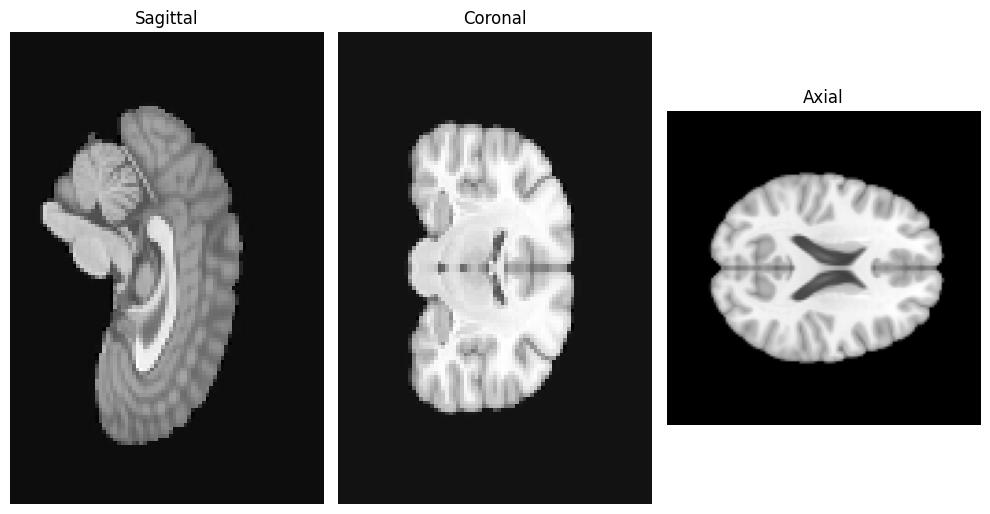

In [59]:

template_img = nib.load(output_path)
template_data = template_img.get_fdata()

print(template_data.shape)
fig, axes = plt.subplots(1, 3, figsize=(10, 10))

# Axial slice
axes[0].imshow(template_data[template_data.shape[0] // 2, :, :], cmap="gray")
axes[0].set_title("Sagittal")
axes[0].axis("off")

# Sagittal slice
axes[1].imshow(template_data[:, template_data.shape[1] // 2, :], cmap="gray")
axes[1].set_title("Coronal")
axes[1].axis("off")

# Coronal slice
axes[2].imshow(template_data[:, :, template_data.shape[2] // 2], cmap="gray")
axes[2].set_title("Axial")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### IXI B1000

In [5]:
b1000_ixi_unprocessed_folder = ROOT_DIR+"datasets/b1000_ixi_skullstrip/"
os.makedirs(b1000_ixi_unprocessed_folder, exist_ok=True)

b1000_ixi_resized_folder = ROOT_DIR+"datasets/b1000_ixi_resized/"
os.makedirs(b1000_ixi_resized_folder, exist_ok=True)

b1000_ixi_output_folder_registered = ROOT_DIR+"datasets/final_b1000_dataset_small/b1000_ixi_registered/"
os.makedirs(b1000_ixi_output_folder_registered, exist_ok=True)


Image 1 shape: (128, 128, 56)
Image 2 shape: (128, 128, 56)
Image 3 shape: (128, 128, 56)
Image 4 shape: (128, 128, 56)


<Figure size 640x480 with 0 Axes>

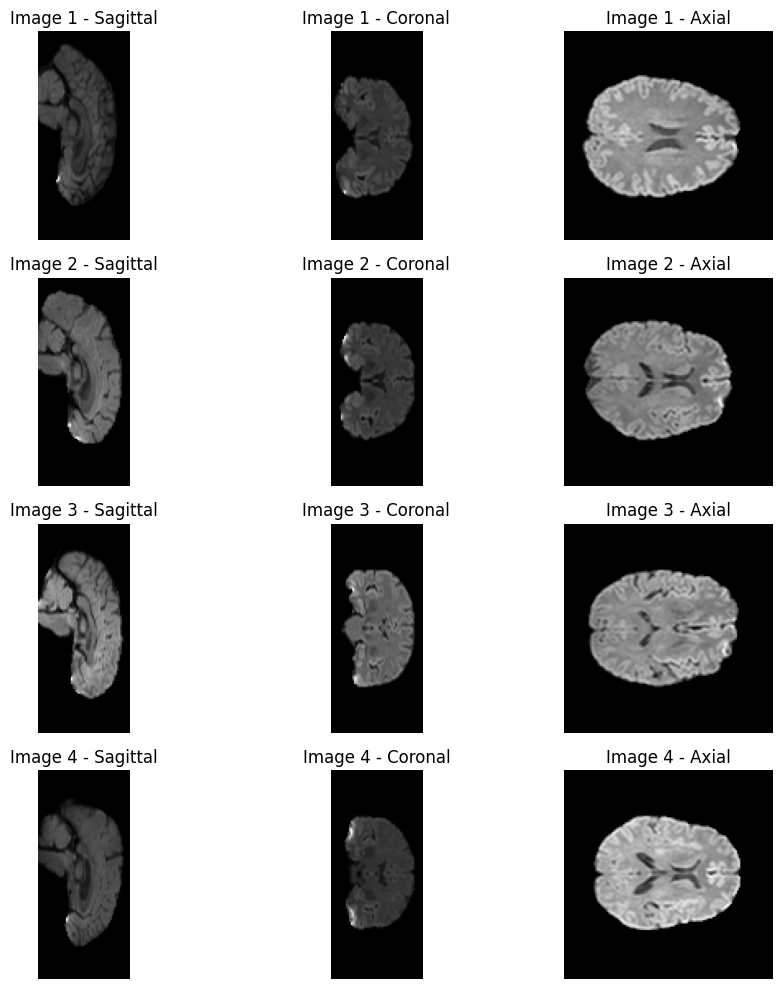

In [6]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(b1000_ixi_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# resample to 1x1x2mm3

for image_path in tqdm(glob.glob(os.path.join(b1000_ixi_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(b1000_ixi_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 396/396 [05:58<00:00,  1.10it/s]


Image 1 shape: (224, 224, 132)
Image 2 shape: (224, 224, 132)
Image 3 shape: (224, 224, 132)
Image 4 shape: (224, 224, 132)


<Figure size 640x480 with 0 Axes>

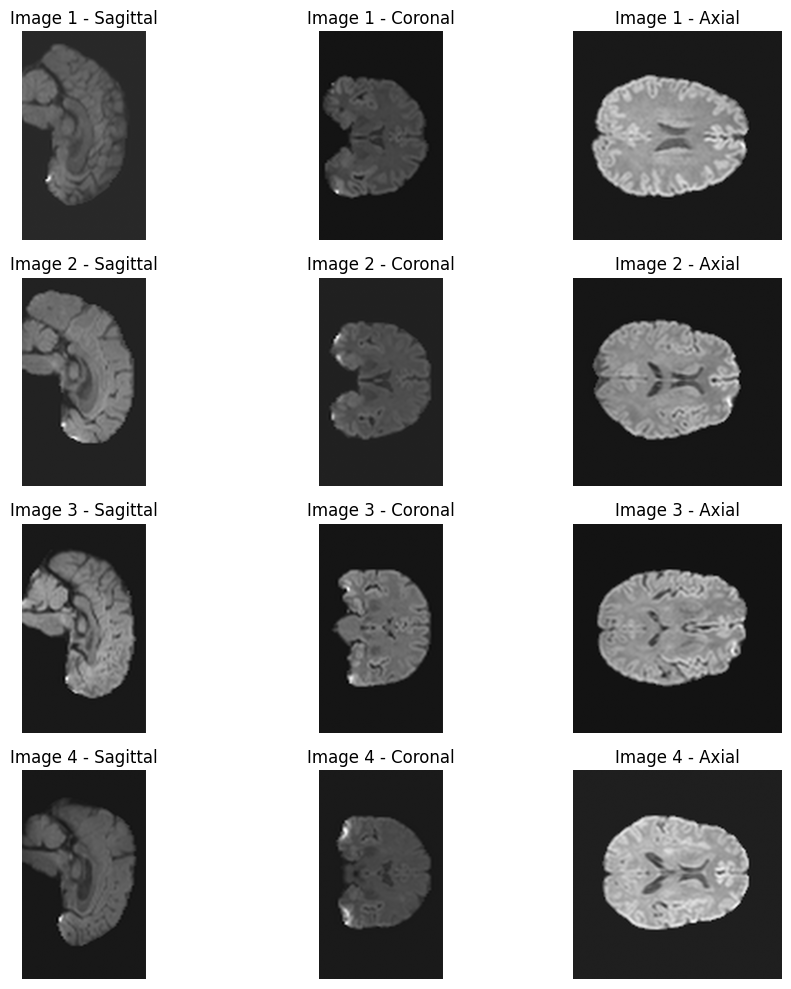

In [8]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(b1000_ixi_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Registration
def process_image_register(image_path, output_folder):
    #print(f"image path: {image_path}")
    #print(f"image basename: {os.path.basename(image_path)}")
    #print(f"output path: {os.path.join(output_folder, os.path.basename(image_path))}")
    moving_image = ants.image_read(image_path)
    fixed_image = ants.image_read(ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_mni_icbm152_t1_skullstrip.nii.gz")

    # Perform registration
    registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

    # Save the registered image
    ants.image_write(registration['warpedmovout'], os.path.join(output_folder, os.path.basename(image_path)))

    #print(f"Registered {moving_file} and saved to {output_filepath}")


image_paths = glob.glob(os.path.join(b1000_ixi_resized_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_register, path, b1000_ixi_output_folder_registered): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

Processing images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 396/396 [01:42<00:00,  3.88it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)
Image 5 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

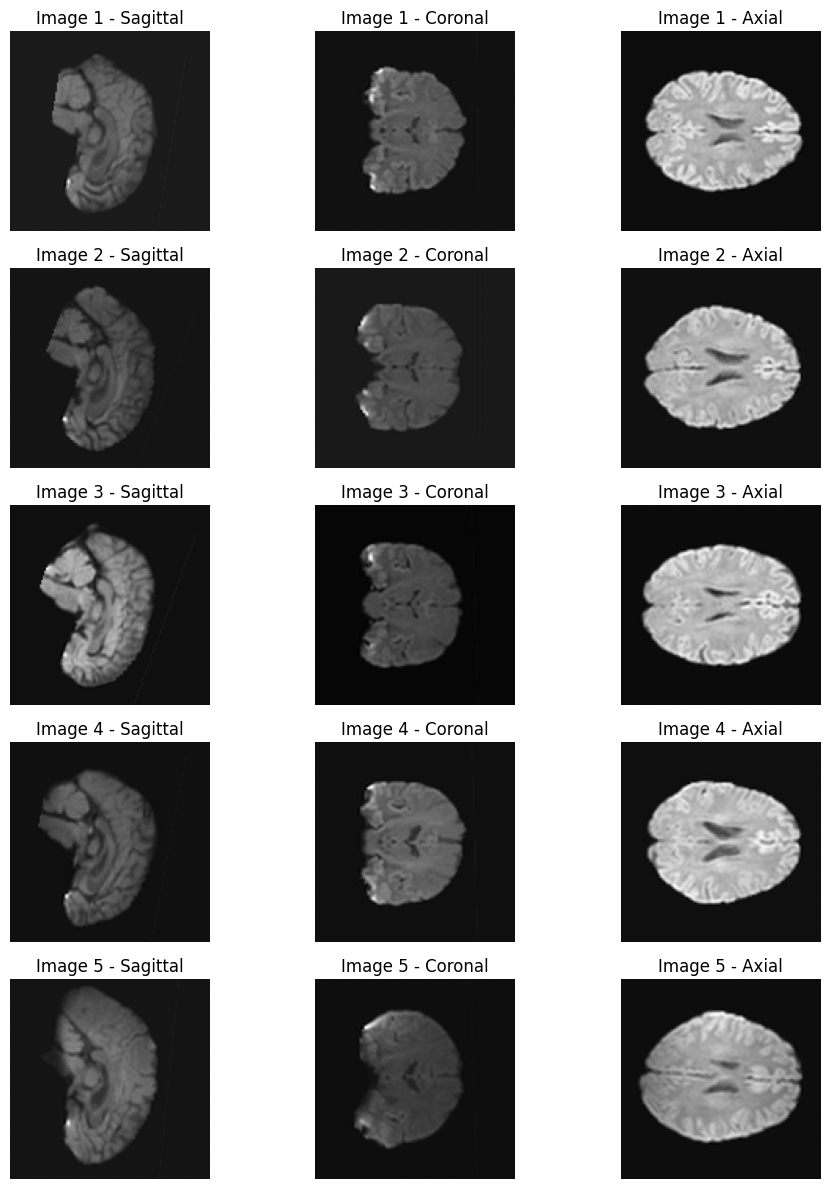

In [10]:
# Get the first 10 image paths from the folder
nb_images_to_display = 5
image_paths = sorted(glob.glob(os.path.join(b1000_ixi_output_folder_registered, "*.nii.gz")))[:nb_images_to_display]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(nb_images_to_display, 3, figsize=(10, 10*nb_images_to_display//4))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

### Dallas B1000

In [ ]:
b1000_dallas_unprocessed_folder = ROOT_DIR+"datasets/b1000_dallas_skullstrip/"
os.makedirs(b1000_dallas_unprocessed_folder, exist_ok=True)

b1000_dallas_resized_folder = ROOT_DIR+"datasets/b1000_dallas_resized/"
os.makedirs(b1000_dallas_resized_folder, exist_ok=True)

b1000_dallas_output_folder_registered = ROOT_DIR+"datasets/final_b1000_dataset_small/b1000_dallas_registered/"
os.makedirs(b1000_dallas_output_folder_registered, exist_ok=True)


Image 1 shape: (128, 128, 56)
Image 2 shape: (128, 128, 56)
Image 3 shape: (128, 128, 56)
Image 4 shape: (128, 128, 56)


<Figure size 640x480 with 0 Axes>

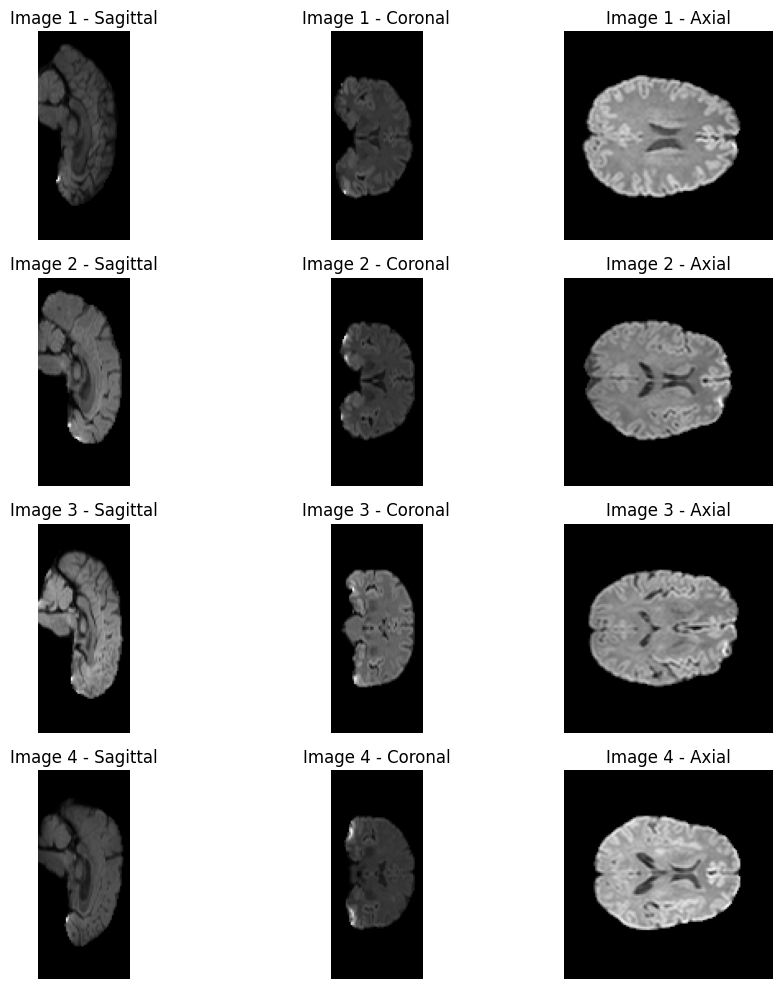

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(b1000_ixi_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# resample to 1x1x2mm3

for image_path in tqdm(glob.glob(os.path.join(b1000_ixi_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image, out_spacing=[1, 1, 1.5])
    output_path = os.path.join(b1000_ixi_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 396/396 [04:57<00:00,  1.33it/s]


Image 1 shape: (224, 224, 88)
Image 2 shape: (224, 224, 88)
Image 3 shape: (224, 224, 88)
Image 4 shape: (224, 224, 88)


<Figure size 640x480 with 0 Axes>

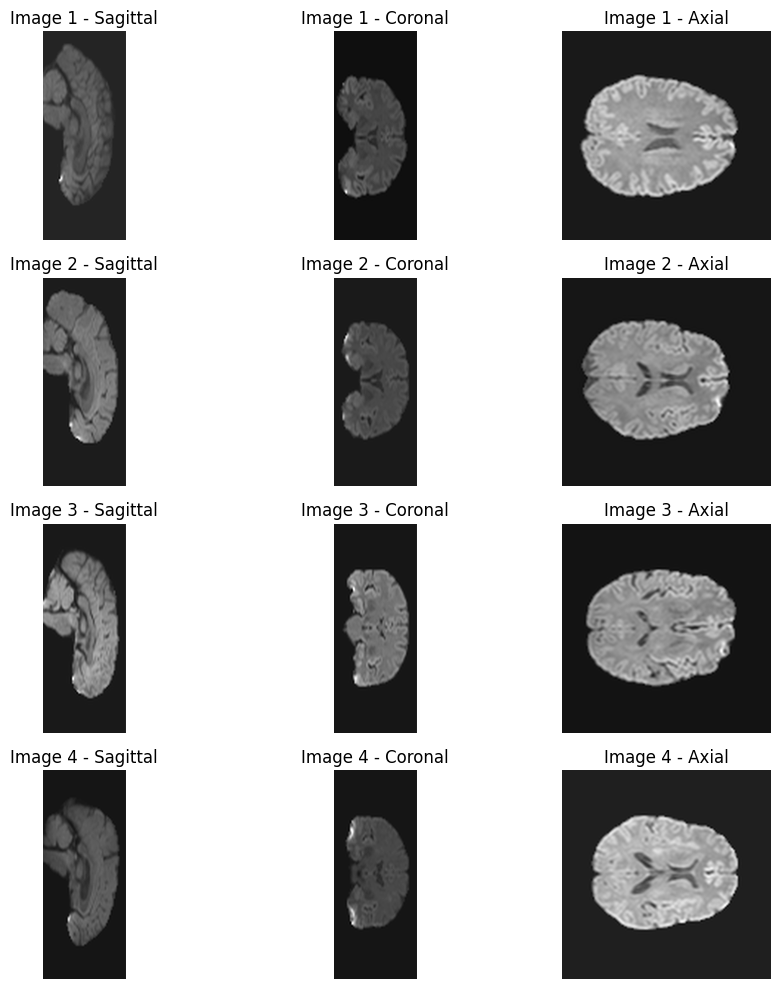

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(b1000_ixi_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Registration
def process_image_register(image_path, output_folder):
    #print(f"image path: {image_path}")
    #print(f"image basename: {os.path.basename(image_path)}")
    #print(f"output path: {os.path.join(output_folder, os.path.basename(image_path))}")
    moving_image = ants.image_read(image_path)
    fixed_image = ants.image_read(ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_mni_icbm152_t1_skullstrip_1x1x1-5.nii.gz")

    # Perform registration
    registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

    # Save the registered image
    ants.image_write(registration['warpedmovout'], os.path.join(output_folder, os.path.basename(image_path)))

    #print(f"Registered {moving_file} and saved to {output_filepath}")


image_paths = glob.glob(os.path.join(b1000_ixi_resized_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_register, path, b1000_ixi_output_folder_registered): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

image path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/1590_b1000.nii.gz
image basename: 1590_b1000.nii.gz
output path: /home/fehrdelt/bettik/datasets/final_b1000_dataset_small/b1000_ixi_registered/1590_b1000.nii.gz

Processing images:   0%|                                                                                                                          | 0/396 [00:00<?, ?it/s]


image path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/0842_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/1050_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/0986_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/1007_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/0955_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/0823_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/0941_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/2607_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/1088_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/1061_b1000.nii.gz


image path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/0922_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/1083_b1000.nii.gzimage path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized

Processing images:   0%|▎                                                                                                               | 1/396 [00:15<1:42:52, 15.63s/it]

image path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/0862_b1000.nii.gz
image basename: 0862_b1000.nii.gz
output path: /home/fehrdelt/bettik/datasets/final_b1000_dataset_small/b1000_ixi_registered/0862_b1000.nii.gz
image path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/1326_b1000.nii.gz

...

Processing images:  91%|██████████████████████████████████████████████████████████████████████████████████████████████████████▍         | 362/396 [04:02<00:22,  1.49it/s]

image path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/2051_b1000.nii.gz
image basename: 2051_b1000.nii.gz
output path: /home/fehrdelt/bettik/datasets/final_b1000_dataset_small/b1000_ixi_registered/2051_b1000.nii.gz


Processing images:  92%|██████████████████████████████████████████████████████████████████████████████████████████████████████▋         | 363/396 [04:02<00:17,  1.92it/s]

image path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/2178_b1000.nii.gz
image basename: 2178_b1000.nii.gz
output path: /home/fehrdelt/bettik/datasets/final_b1000_dataset_small/b1000_ixi_registered/2178_b1000.nii.gz
image path: /home/fehrdelt/bettik/datasets/b1000_ixi_resized/1051_b1000.nii.gz
image basename: 1051_b1000.nii.gz
output path: /home/fehrdelt/bettik/datasets/final_b1000_dataset_small/b1000_ixi_registered/1051_b1000.nii.gz


Processing images: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 396/396 [04:10<00:00,  1.58it/s]


Image 1 shape: (128, 128, 85)
Image 2 shape: (128, 128, 85)
Image 3 shape: (128, 128, 85)
Image 4 shape: (128, 128, 85)
Image 5 shape: (128, 128, 85)


<Figure size 640x480 with 0 Axes>

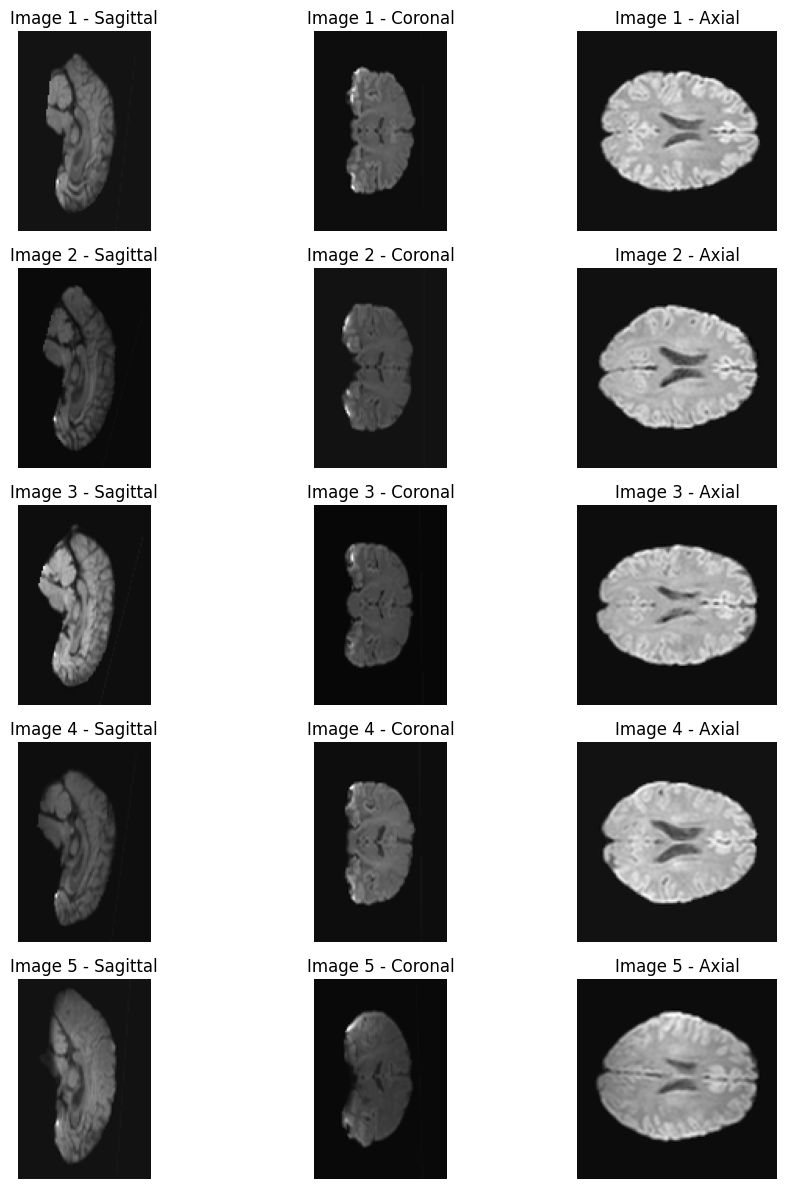

In [ ]:
# Get the first 10 image paths from the folder
nb_images_to_display = 5
image_paths = sorted(glob.glob(os.path.join(b1000_ixi_output_folder_registered, "*.nii.gz")))[:nb_images_to_display]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(nb_images_to_display, 3, figsize=(10, 10*nb_images_to_display//4))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()